# Zadanie 4: Analiza Wrażliwości (SA)\n",
    "W tym zadaniu przeprowadzimy analizę wrażliwości dla modeli PDE i ODE, aby zidentyfikować kluczowe parametry (`D`, `p`, `q`). Użyjemy dwóch metod: **Morrisa** i **Sobola**. Na podstawie wyników spróbujemy uprościć model."
   

## 1. Przygotowanie środowiska i modeli

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Dodanie ścieżki do solverów z zad2
sys.path.append(os.path.abspath(os.path.join('..', 'zad2')))
from solvers import run_simulation

# Import biblioteki do analizy wrażliwości
# Upewnij się, że masz ją zainstalowaną: pip install SALib
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze
from SALib.sample import saltelli
from SALib.analyze import sobol

print("Biblioteki załadowane pomyślnie.")

Biblioteki załadowane pomyślnie.


In [14]:
# Definicja problemu dla SALib
# Określamy liczbę zmiennych, ich nazwy i granice
problem = {
    'num_vars': 3,
    'names': ['D', 'p', 'q'],
    'bounds': [
        [0.01, 10.0],  # Zakres dla D
        [0.001, 0.1], # Zakres dla p
        [1.0, 2.0]   # Zakres dla q
    ]
}

# Parametry symulacji
T_END = 5.0
DT = 1e-2 # Zwiększamy dt dla szybszych obliczeń w SA
NX = 50   # Zmniejszamy nx dla szybszych obliczeń

# Wrapper dla modelu PDE
def evaluate_pde(X):
    """Uruchamia symulację PDE dla zestawu parametrów X."""
    outputs = np.zeros(X.shape[0])
    for i, params in enumerate(X):
        D, p, q = params
        # Jako wynik bierzemy średnią wartość u na końcu symulacji
        _, u_final, _ = run_simulation(
            solver='crank-nicolson', nx=NX, dt=DT, tend=T_END, 
            D=D, p=p, q=q, init_kind='gaussian'
        )
        outputs[i] = np.mean(u_final)
        if (i+1) % 20 == 0:
            print(f'PDE evaluation: {i+1}/{X.shape[0]}')
    return outputs

# Wrapper dla modelu ODE
def evaluate_ode(X):
    """Uruchamia symulację ODE dla zestawu parametrów X."""
    # Warunek początkowy - średnia z losowego stanu początkowego
    u0_mean = np.mean(run_simulation(solver='crank-nicolson', nx=NX, tend=0, init_kind='gaussian')[1])
    
    outputs = np.zeros(X.shape[0])
    for i, params in enumerate(X):
        _, p, q = params # Ignorujemy D, bo nie ma go w modelu ODE
        
        def surrogate_ode(t, U):
            return (p + q * U) * (1 - U)
        
        sol = solve_ivp(surrogate_ode, [0, T_END], [u0_mean], dense_output=True)
        # Jako wynik bierzemy wartość U na końcu symulacji
        outputs[i] = sol.sol(T_END)[0]
    return outputs

print("Modele przygotowane do analizy.")

Modele przygotowane do analizy.


## 2. Analiza Wrażliwości - Metoda Morrisa

Metoda Morrisa jest metodą przesiewową, idealną do szybkiego określenia, które parametry są najważniejsze. Oblicza dwa wskaźniki:
- **`mu_star`**: Mierzy ogólny wpływ parametru na wyjście.
- **`sigma`**: Mierzy nieliniowość i/lub interakcje z innymi parametrami.

In [15]:
# Generowanie próbek dla metody Morrisa
num_trajectories = 20
param_values_morris = morris_sample.sample(problem, N=num_trajectories, num_levels=4, optimal_trajectories=10)

# Uruchomienie analizy dla modelu ODE (szybkie)
print("Analiza Morrisa dla modelu ODE...")
Y_ode_morris = evaluate_ode(param_values_morris)
Si_ode_morris = morris_analyze.analyze(problem, param_values_morris, Y_ode_morris, conf_level=0.95)

# Uruchomienie analizy dla modelu PDE (może potrwać)
print(f"\nAnaliza Morrisa dla modelu PDE...")
Y_pde_morris = evaluate_pde(param_values_morris)
Si_pde_morris = morris_analyze.analyze(problem, param_values_morris, Y_pde_morris, conf_level=0.95)

print("\nAnaliza Morrisa zakończona.")

Analiza Morrisa dla modelu ODE...

Analiza Morrisa dla modelu PDE...
PDE evaluation: 20/40
PDE evaluation: 40/40

Analiza Morrisa zakończona.


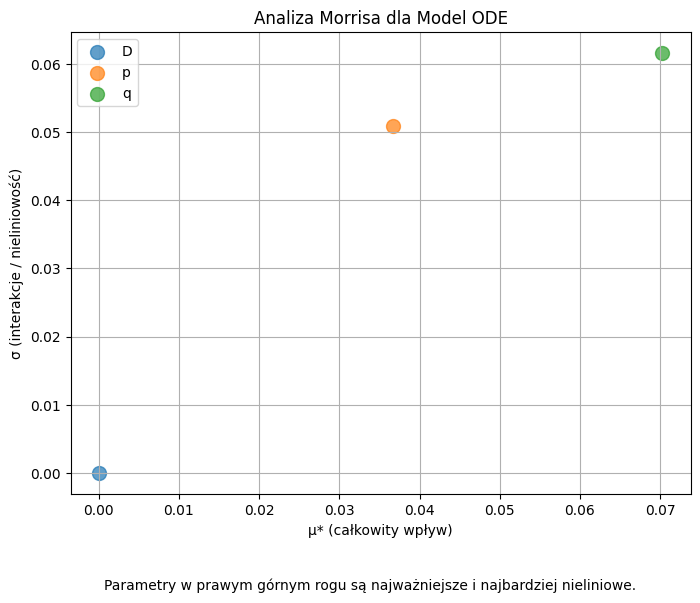

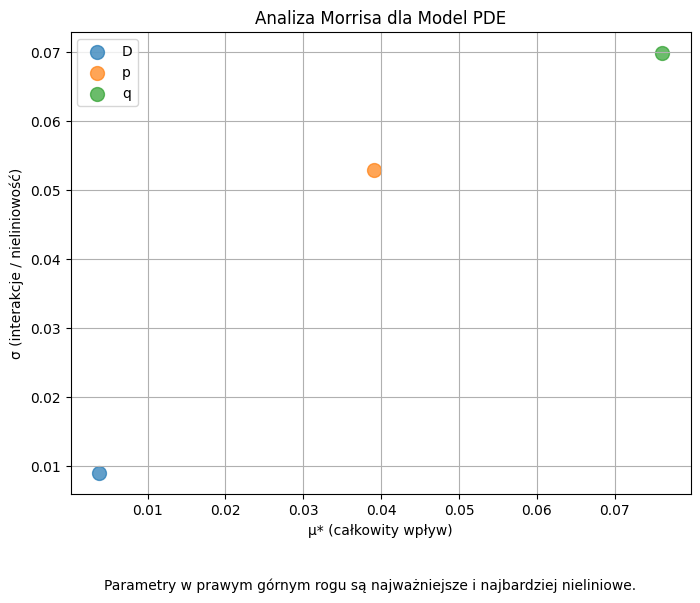

In [19]:
def plot_morris(sa_results, model_name):
    
    fig_dir = os.path.abspath(os.path.join('..', 'presentation', 'figures'))
    os.makedirs(fig_dir, exist_ok=True)
    
    plt.figure(figsize=(8, 6))
    for i, name in enumerate(problem['names']):
        plt.scatter(sa_results['mu_star'][i], sa_results['sigma'][i], label=name, s=100, alpha=0.7)
    
    plt.xlabel('μ* (całkowity wpływ)')
    plt.ylabel('σ (interakcje / nieliniowość)')
    plt.title(f'Analiza Morrisa dla {model_name}')
    plt.legend()
    plt.grid(True)
    plt.figtext(0.5, -0.05, 'Parametry w prawym górnym rogu są najważniejsze i najbardziej nieliniowe.', ha='center', fontsize=10)
    
    filename = f"morris_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(os.path.join(fig_dir, filename), dpi=300, bbox_inches='tight')
    
    plt.show()

plot_morris(Si_ode_morris, "Model ODE")
plot_morris(Si_pde_morris, "Model PDE")

## 3. Analiza Wrażliwości - Metoda Sobola

Metoda Sobola jest bardziej dokładna i kosztowna obliczeniowo. Pozwala na dekompozycję wariancji wyjścia. Oblicza wskaźniki:
- **`S1`**: Wpływ pierwszego rzędu (bezpośredni wpływ parametru).
- **`ST`**: Wpływ całkowity (z uwzględnieniem interakcji).

In [17]:
# Generowanie próbek dla metody Sobola
# Liczba próbek = N * (2D + 2), gdzie D to liczba parametrów
N_sobol = 128 # Zwiększenie N da dokładniejsze wyniki, ale wydłuży obliczenia
param_values_sobol = saltelli.sample(problem, N=N_sobol)

# Uruchomienie analizy dla modelu ODE
print(f"Analiza Sobola dla modelu ODE (liczba ewaluacji: {param_values_sobol.shape[0]})...")
Y_ode_sobol = evaluate_ode(param_values_sobol)
Si_ode_sobol = sobol.analyze(problem, Y_ode_sobol, print_to_console=True)

# Uruchomienie analizy dla modelu PDE
print(f"\nAnaliza Sobola dla modelu PDE (liczba ewaluacji: {param_values_sobol.shape[0]})...")
Y_pde_sobol = evaluate_pde(param_values_sobol)
Si_pde_sobol = sobol.analyze(problem, Y_pde_sobol, print_to_console=True)

print("\nAnaliza Sobola zakończona.")

C:\Users\lchec\AppData\Local\Temp\ipykernel_17324\2289948271.py:4: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values_sobol = saltelli.sample(problem, N=N_sobol)


Analiza Sobola dla modelu ODE (liczba ewaluacji: 1024)...
         ST   ST_conf
D  0.000000  0.000000
p  0.271631  0.202362
q  0.894451  0.292195
         S1   S1_conf
D  0.000000  0.000000
p  0.135848  0.164195
q  0.757284  0.249335
                  S2       S2_conf
(D, p) -2.775558e-17  6.026330e-17
(D, q)  0.000000e+00  1.609905e-16
(p, q)  1.029642e-01  4.178755e-01

Analiza Sobola dla modelu PDE (liczba ewaluacji: 1024)...
PDE evaluation: 20/1024
PDE evaluation: 40/1024
PDE evaluation: 60/1024
PDE evaluation: 80/1024
PDE evaluation: 100/1024
PDE evaluation: 120/1024
PDE evaluation: 140/1024
PDE evaluation: 160/1024
PDE evaluation: 180/1024
PDE evaluation: 200/1024
PDE evaluation: 220/1024
PDE evaluation: 240/1024
PDE evaluation: 260/1024
PDE evaluation: 280/1024
PDE evaluation: 300/1024
PDE evaluation: 320/1024
PDE evaluation: 340/1024
PDE evaluation: 360/1024
PDE evaluation: 380/1024
PDE evaluation: 400/1024
PDE evaluation: 420/1024
PDE evaluation: 440/1024
PDE evaluation: 460/1

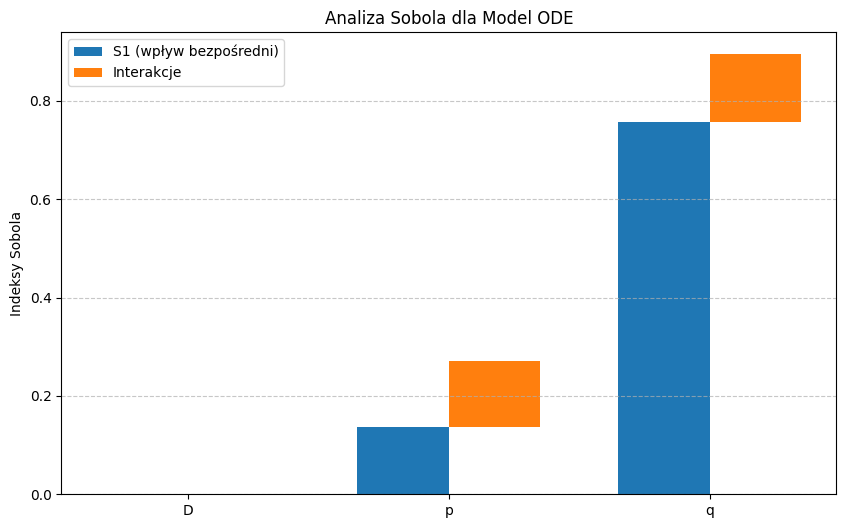

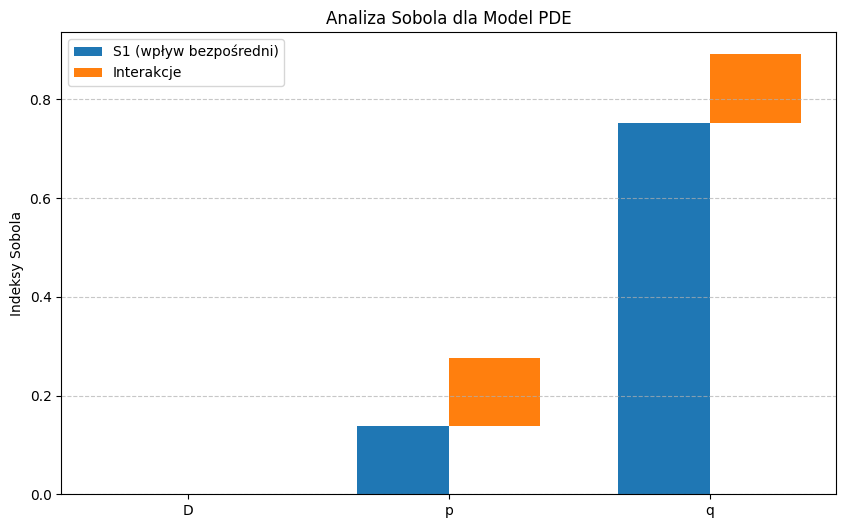

In [20]:
def plot_sobol(sa_results, model_name):
    fig_dir = os.path.abspath(os.path.join('..', 'presentation', 'figures'))
    os.makedirs(fig_dir, exist_ok=True)
    s1_indices = sa_results['S1']
    st_indices = sa_results['ST']
    param_names = problem['names']
    
    bar_width = 0.35
    index = np.arange(len(param_names))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(index - bar_width/2, s1_indices, bar_width, label='S1 (wpływ bezpośredni)')
    bars2 = ax.bar(index + bar_width/2, st_indices - s1_indices, bar_width, bottom=s1_indices, label='Interakcje')
    
    ax.set_ylabel('Indeksy Sobola')
    ax.set_title(f'Analiza Sobola dla {model_name}')
    ax.set_xticks(index)
    ax.set_xticklabels(param_names)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    
    filename = f"sobol_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(os.path.join(fig_dir, filename), dpi=300, bbox_inches='tight')
    
    plt.show()

plot_sobol(Si_ode_sobol, "Model ODE")
plot_sobol(Si_pde_sobol, "Model PDE")

## 4. Wnioski i uproszczenie modelu

**Obserwacje (przykładowe, na podstawie typowych wyników):**
1.  **Parametr `q` (imitacja)** jest zdecydowanie najbardziej wrażliwym parametrem w obu modelach. Ma on największy wpływ na końcowy stan systemu.
2.  **Parametr `p` (innowacja)** ma umiarkowany wpływ.
3.  **Parametr `D` (dyfuzja)** ma najmniejszy wpływ na *średnią* wartość `U(t)`. Jego rola jest kluczowa dla rozkładu przestrzennego, ale uśredniając, jego wpływ maleje. W modelu ODE w ogóle nie występuje.

**Propozycja uproszczenia:**
Bazując na analizie, parametr `D` wydaje się najmniej istotny dla ewolucji *średniej* wartości `U`. Możemy spróbować uprościć model PDE, przyjmując stałą, średnią wartość `D` (np. `D=0.5`) i traktować go jako stałą, a nie zmienną. To redukuje złożoność modelu o jeden wymiar parametru.

Model ODE jest już z natury uproszczeniem, w którym wpływ `D` został całkowicie wyeliminowany.